In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.miscmodels.ordinal_model import OrderedModel

data_path = "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols_with_subtype_probas.csv"
time_col = "time"
cat_levels = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

# Keep full longitudinal panel by default.
df_all = pd.read_csv(data_path)


def build_ordinal_panel(df, feature_cols):
    panel_df = df.copy()
    panel_df["NSD_STAGE"] = pd.to_numeric(panel_df["NSD_STAGE"], errors="coerce")
    panel_df.loc[panel_df["NSD_STAGE"] == 0, "NSD_STAGE"] = np.nan
    panel_df["NSD_ordered"] = pd.Categorical(
        panel_df["NSD_STAGE"], categories=cat_levels, ordered=True
    )

    # Only require columns needed for current model.
    cols_needed = ["NSD_ordered", "subj_id", "model_split_best"] + feature_cols
    model_df = panel_df[cols_needed].copy()

    # Force predictors numeric, then drop NaN/inf rows.
    model_df[feature_cols] = model_df[feature_cols].apply(pd.to_numeric, errors="coerce")
    model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_needed).copy()

    ord_train = model_df[model_df["model_split_best"] == "train"].copy()
    ord_val = model_df[model_df["model_split_best"] == "val"].copy()

    # Critical for OrderedModel stability: fit on observed train classes only.
    ord_train["NSD_ordered"] = pd.Categorical(
        ord_train["NSD_ordered"].astype(float), categories=cat_levels, ordered=True
    )
    ord_train["NSD_ordered"] = ord_train["NSD_ordered"].cat.remove_unused_categories()

    train_cats = ord_train["NSD_ordered"].cat.categories
    ord_val["NSD_ordered"] = pd.Categorical(
        ord_val["NSD_ordered"].astype(float), categories=train_cats, ordered=True
    )
    # Drop validation rows with classes not seen in train.
    ord_val = ord_val.dropna(subset=["NSD_ordered"]).copy()

    return model_df, ord_train, ord_val


base_features = ["MCATOT", "TD_score", "PIGD_score"]
model_df, ord_train, ord_val = build_ordinal_panel(df_all, base_features)
full_cats = pd.Index(cat_levels)

print("\nRows by model_split_best:")
print(df_all["model_split_best"].value_counts(dropna=False))
print("\nUnique subjects by model_split_best:")
print(df_all.groupby("model_split_best")["subj_id"].nunique())
print("\nLongitudinal complete cases for base model:")
print("Train n:", len(ord_train), "| Val n:", len(ord_val))
print("Train NSD counts:\n", ord_train["NSD_ordered"].value_counts().sort_index())
print("Val NSD counts:\n", ord_val["NSD_ordered"].value_counts().sort_index())


Rows by model_split_best:
model_split_best
train       513
not_used    235
val         132
Name: count, dtype: int64

Unique subjects by model_split_best:
model_split_best
not_used    231
train       116
val          30
Name: subj_id, dtype: int64

Longitudinal complete cases for base model:
Train n: 401 | Val n: 105
Train NSD counts:
 NSD_ordered
1.0      0
2.0      0
3.0    309
4.0     86
5.0      5
6.0      1
Name: count, dtype: int64
Val NSD counts:
 NSD_ordered
1.0     0
2.0     0
3.0    73
4.0    29
5.0     3
6.0     0
Name: count, dtype: int64


In [57]:
print(df_all["subtype_best"].value_counts(dropna=True))

subtype_best
0.0    330
1.0    224
2.0     91
Name: count, dtype: int64


In [58]:
class WeightedOrderedModel(OrderedModel):
    def __init__(self, endog, exog, sample_weights=None, distr="logit", **kwargs):
        super().__init__(endog, exog, distr=distr, **kwargs)
        if sample_weights is None:
            sample_weights = np.ones(self.nobs)
        w = np.asarray(sample_weights, dtype=float)
        self.sample_weights = w * (self.nobs / w.sum())

    def loglikeobs(self, params):
        return self.sample_weights * super().loglikeobs(params)

    def score_obs(self, params):
        return self.sample_weights[:, None] * super().score_obs(params)

## Ord regression clinical scores only

                          WeightedOrderedModel Results                          
Dep. Variable:              NSD_ordered   Log-Likelihood:                    nan
Model:             WeightedOrderedModel   AIC:                               nan
Method:              Maximum Likelihood   BIC:                               nan
Date:                  Tue, 28 Apr 2026                                         
Time:                          15:17:43                                         
No. Observations:                   401                                         
Df Residuals:                       393                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MCATOT              0        nan        nan        nan         nan         nan
TD_score            0        nan  

/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in add
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:158: RuntimeWarning: invalid value encountered in subtract
  f(*((x-ei,)+args), **kwargs))/(2 * epsilon[k])
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:453: RuntimeWarning: invalid value encountered in add
  (f(*((x + ee[i, :] + ee[j, :],) + args), **kwargs)
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:455: RuntimeWarning: invalid value encountered in add
  - (f(*((x - ee[i, :] + ee[j, :],) + args), **kwargs)


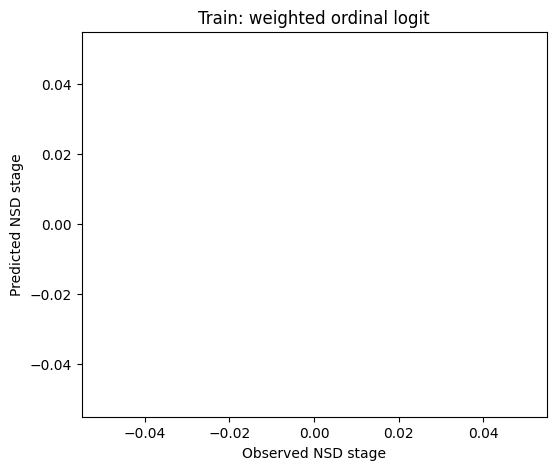

Train accuracy: 0.0000


In [59]:
y_train = ord_train["NSD_ordered"].cat.remove_unused_categories()
X_train = ord_train[["MCATOT", "TD_score", "PIGD_score"]].apply(pd.to_numeric, errors="coerce")

# Safety cleanup for ordinal fit.
mask_finite = np.isfinite(X_train.to_numpy()).all(axis=1)
y_train = y_train.loc[mask_finite].copy()
X_train = X_train.loc[mask_finite].copy()

# Rare classes can destabilize weighted ordinal MLE; drop classes with <2 rows.
counts = y_train.value_counts().sort_index()
rare_classes = counts[counts < 2].index
if len(rare_classes) > 0:
    keep_mask = ~y_train.isin(rare_classes)
    print("Dropping rare train classes (<2 rows):", list(rare_classes.astype(float)))
    y_train = y_train.loc[keep_mask].copy()
    X_train = X_train.loc[keep_mask].copy()
    y_train = y_train.cat.remove_unused_categories()

print("Train NSD counts used for weighted fit:\n", y_train.value_counts().sort_index())

w_train = compute_sample_weight(class_weight="balanced", y=y_train)
# Clip extreme class weights to improve numerical stability.
w_train = np.clip(w_train, np.percentile(w_train, 5), np.percentile(w_train, 95))

mod_train = WeightedOrderedModel(y_train, X_train, sample_weights=w_train, distr="logit")
res_train = mod_train.fit(method="bfgs", disp=False, cov_type="HC1", maxiter=300)
print(res_train.summary())

pred_probas_train = res_train.model.predict(params=res_train.params, exog=X_train)
pred_idx_train = np.argmax(pred_probas_train, axis=1)
pred_cat_train = pd.Series(full_cats[pred_idx_train], index=y_train.index).astype(float)
true_cat_train = y_train.astype(float)

plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_train, y=pred_cat_train, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("Train: weighted ordinal logit")
plt.show()
print(f"Train accuracy: {np.mean(pred_cat_train.values == true_cat_train.values):.4f}")


/tmp/ipykernel_10647/1274720230.py:9: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)


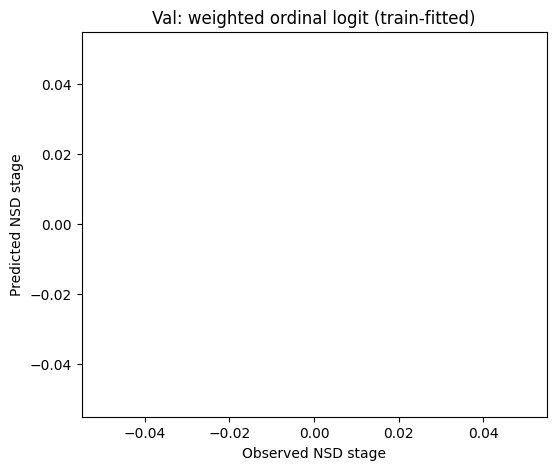

Val accuracy: 0.0000
0.0
0.0


In [60]:

y_val = ord_val["NSD_ordered"]
X_val = ord_val[["MCATOT", "TD_score", "PIGD_score"]]
pred_probas_val = res_train.model.predict(params=res_train.params, exog=X_val)
pred_idx_val = np.argmax(pred_probas_val, axis=1)
pred_cat_val = pd.Series(full_cats[pred_idx_val], index=y_val.index).astype(float)
true_cat_val = y_val.astype(float)

plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("Val: weighted ordinal logit (train-fitted)")
plt.show()
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

from sklearn.metrics import f1_score

# train (use your pred_cat_train / true_cat_train)
f1_train = f1_score(true_cat_train,pred_cat_train,average="weighted",labels=full_cats.astype(float),zero_division=0)
# val
f1_val = f1_score(true_cat_val,pred_cat_val,average="weighted",labels=full_cats.astype(float),zero_division=0)
print(f1_train)
print(f1_val)

### ord regression with subtype

In [61]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight

SUBTYPE = [0, 1, 2]
clin_cols = ["MCATOT", "TD_score", "PIGD_score"]

sub_train = pd.Series(
    pd.Categorical(ord_train["subtype_best"].astype(int), categories=SUBTYPE),
    index=ord_train.index,
)
subtype_dummies = pd.get_dummies(
    sub_train, prefix="subtype", prefix_sep="_", drop_first=True
).astype(int)
X_train_sub = pd.concat([ord_train[clin_cols], subtype_dummies], axis=1)

w_train = compute_sample_weight(class_weight="balanced", y=ord_train["NSD_ordered"])
mod_sub = WeightedOrderedModel(
    ord_train["NSD_ordered"], X_train_sub, sample_weights=w_train, distr="logit"
)
res_sub = mod_sub.fit(method="bfgs", disp=False, cov_type="HC1")
print(res_sub.summary())

sub_val = pd.Series(
    pd.Categorical(ord_val["subtype_best"].astype(int), categories=SUBTYPE),
    index=ord_val.index,
)
subtype_dummies_val = pd.get_dummies(
    sub_val, prefix="subtype", prefix_sep="_", drop_first=True
).astype(int)
subtype_dummies_val = subtype_dummies_val.reindex(
    columns=subtype_dummies.columns, fill_value=0
)
X_val_sub = pd.concat([ord_val[clin_cols], subtype_dummies_val], axis=1)


KeyError: 'subtype_best'

In [ ]:
pred_probas_train = res_sub.model.predict(params=res_sub.params, exog=X_train_sub)
pred_idx_train = np.argmax(pred_probas_train, axis=1)
pred_cat_train = pd.Series(
    full_cats[pred_idx_train], index=ord_train["NSD_ordered"].index
).astype(float)
true_cat_train = ord_train["NSD_ordered"].astype(float)
print(f"Train accuracy: {np.mean(pred_cat_train.values == true_cat_train.values):.4f}")

pred_probas_val = res_sub.model.predict(params=res_sub.params, exog=X_val_sub)
pred_idx_val = np.argmax(pred_probas_val, axis=1)
pred_cat_val = pd.Series(
    full_cats[pred_idx_val], index=ord_val["NSD_ordered"].index
).astype(float)
true_cat_val = ord_val["NSD_ordered"].astype(float)
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

Train accuracy: 0.5714
Val accuracy: 0.4000


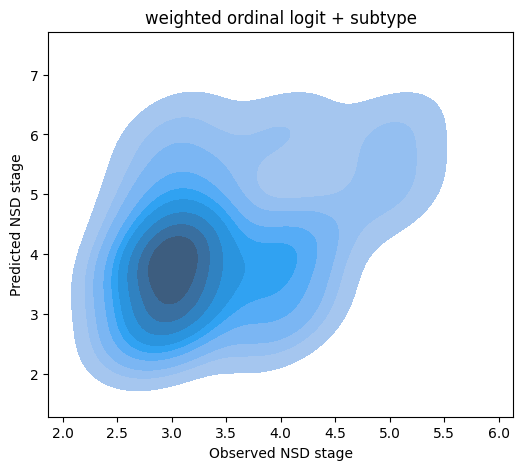

Val accuracy: 0.4000
f1 train: 0.4458333333333333
f1 val: 0.30823529411764705


In [ ]:
plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("weighted ordinal logit + subtype")
plt.show()
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

from sklearn.metrics import f1_score

f1_train = f1_score(true_cat_train,pred_cat_train,average="macro",labels=full_cats.astype(float),zero_division=0)
f1_val = f1_score(true_cat_val,pred_cat_val,average="macro",labels=full_cats.astype(float),zero_division=0)
print(f"f1 train: {f1_train}")
print(f"f1 val: {f1_val}")

## respecting longitudinal whatevers

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Reuse panel builder to avoid stale category handling.
FEATURES = ["MCATOT", "TD_score", "PIGD_score", "beta_0", "beta_1", "beta_2"]
model_df, ord_train, ord_val = build_ordinal_panel(df_all, FEATURES)

y_train = ord_train["NSD_ordered"]
X_train = ord_train[FEATURES]
y_val = ord_val["NSD_ordered"]
X_val = ord_val[FEATURES]

print("Beta-model train NSD counts:\n", y_train.value_counts().sort_index())
print("Beta-model val NSD counts:\n", y_val.value_counts().sort_index())

In [ ]:
# Longitudinal ordered logit with beta features (robust cleaning + diagnostics)
beta_features = ["MCATOT", "TD_score", "PIGD_score", "beta_0", "beta_1", "beta_2"]
model_df_beta, ord_train_beta, ord_val_beta = build_ordinal_panel(df_all, beta_features)

X_train_beta = ord_train_beta[beta_features].copy()
y_train_beta = ord_train_beta["NSD_ordered"]

# Drop zero-variance predictors; they can break OrderedModel numerics.
std_train = X_train_beta.std(ddof=0)
constant_cols = std_train[std_train == 0].index.tolist()
if constant_cols:
    print("Dropping constant train columns:", constant_cols)
    beta_features_fit = [c for c in beta_features if c not in constant_cols]
else:
    beta_features_fit = beta_features

X_train_beta = ord_train_beta[beta_features_fit].astype(float)

# Ensure finite matrix and at least 2 classes.
bad_rows = ~np.isfinite(X_train_beta.to_numpy()).all(axis=1)
if bad_rows.any():
    print("Dropping non-finite train rows:", int(bad_rows.sum()))
    X_train_beta = X_train_beta.loc[~bad_rows].copy()
    y_train_beta = y_train_beta.loc[X_train_beta.index].copy()

print("Train rows:", len(X_train_beta))
print("Predictors used:", beta_features_fit)
print("Any NaN in X_train:", bool(X_train_beta.isna().any().any()))
print("Any inf in X_train:", bool(np.isinf(X_train_beta.to_numpy()).any()))
print("Train NSD counts:\n", y_train_beta.value_counts().sort_index())

if y_train_beta.nunique() < 2:
    raise ValueError("Need at least 2 NSD classes in training data after cleaning.")

mod_beta = OrderedModel(y_train_beta, X_train_beta, distr="logit")
res_beta = mod_beta.fit(
    method="bfgs",
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": ord_train_beta.loc[X_train_beta.index, "subj_id"]},
)

print(res_beta.summary())

In [ ]:
# Use robustly cleaned beta-model objects from the previous cell.
mod = OrderedModel(y_train_beta, X_train_beta, distr="logit")
res = mod.fit(
    method="bfgs",
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": ord_train_beta.loc[X_train_beta.index, "subj_id"]},
    maxiter=300,
)
print(res.summary())

                             OrderedModel Results                             
Dep. Variable:            NSD_ordered   Log-Likelihood:                    nan
Model:                   OrderedModel   AIC:                               nan
Method:            Maximum Likelihood   BIC:                               nan
Date:                Tue, 28 Apr 2026                                         
Time:                        15:03:26                                         
No. Observations:                 401                                         
Df Residuals:                     390                                         
Df Model:                           6                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MCATOT              0        nan        nan        nan         nan         nan
TD_score            0        nan        nan        n

/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in add
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:158: RuntimeWarning: invalid value encountered in subtract
  f(*((x-ei,)+args), **kwargs))/(2 * epsilon[k])
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:453: RuntimeWarning: invalid value encountered in add
  (f(*((x + ee[i, :] + ee[j, :],) + args), **kwargs)
/home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/statsmodels/tools/numdiff.py:455: RuntimeWarning: invalid value encountered in add
  - (f(*((x - ee[i, :] + ee[j, :],) + args), **kwargs)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

# category scale used in the model
full_cats = y_train.cat.categories  # e.g., Index([1,2,3,4,5,6], dtype='int64')

# predicted class probabilities
pred_probas_train = res.model.predict(params=res.params, exog=X_train)
pred_probas_val   = res.model.predict(params=res.params, exog=X_val)

# convert probs -> stage by argmax over ordered categories
pred_idx_train = np.asarray(pred_probas_train).argmax(axis=1)
pred_idx_val   = np.asarray(pred_probas_val).argmax(axis=1)

pred_cat_train = pd.Series(full_cats[pred_idx_train], index=y_train.index).astype(float)
pred_cat_val   = pd.Series(full_cats[pred_idx_val],   index=y_val.index).astype(float)

true_cat_train = y_train.astype(float)
true_cat_val   = y_val.astype(float)

# plot (validation)
plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("Ordinal logit (longitudinal pooled, clustered SE)")
plt.show()

# metrics
acc_train = accuracy_score(true_cat_train, pred_cat_train)
acc_val   = accuracy_score(true_cat_val, pred_cat_val)
print(f"Train accuracy: {acc_train:.4f}")
print(f"Val accuracy:   {acc_val:.4f}")

f1_train = f1_score(
    true_cat_train, pred_cat_train,
    average="macro",
    labels=full_cats.astype(float),
    zero_division=0
)
f1_val = f1_score(
    true_cat_val, pred_cat_val,
    average="macro",
    labels=full_cats.astype(float),
    zero_division=0
)
print(f"F1 train (macro): {f1_train:.4f}")
print(f"F1 val   (macro): {f1_val:.4f}")

ValueError: shapes (25,3) and (6,) not aligned: 3 (dim 1) != 6 (dim 0)

## ulimate BG model supreme

In [ ]:
"""
Continuation-ratio / discrete-time survival ordinal regression for
longitudinal panel data, with sklearn-compatible API.
"""

from __future__ import annotations

import inspect
from typing import Optional, Sequence, Union

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.validation import check_is_fitted


class OrdinalDiscreteTimeSurvival(BaseEstimator, ClassifierMixin):
    """
    Continuation-ratio / discrete-time survival ordinal classifier for
    longitudinal panel data.

    For an ordered target with classes c_1 < c_2 < ... < c_K, fits K-1
    independent binary "hazard" models, one per threshold. For threshold
    k (separating c_k from c_{k+1}), the model estimates

        h_k(j; x) = P(Y_{i,j} >= c_{k+1} | not-yet-crossed, x_{i,j})

    on the at-risk subset (subjects who have not yet crossed k) at each
    visit j. Subjects are right-censored at their last observed visit if
    they never cross.

    At prediction time, hazards are accumulated within subject in time
    order to give monotone (in visit) cumulative threshold-crossing
    probabilities

        F_k(j) = 1 - prod_{j' <= j} (1 - h_k(j'; x_{j'}))

    from which per-class probabilities at each visit are derived via the
    continuation-ratio identity.

    Parameters
    ----------
    order : array-like, optional
        Expected ordered class values, lowest to highest. REQUIRED if y
        is non-numeric. If y is numeric and `order` is None, classes are
        taken as np.unique(y) sorted ascending. Raises if y contains any
        value not in `order`.

    base_estimator : sklearn classifier, optional
        Binary classifier with `predict_proba`. One clone is fitted per
        threshold. Default: LogisticRegression(max_iter=1000).

    subj_id_col, time_col : str
        Names of the subject-id and within-subject relative-time columns
        in X. Time values are used only to ORDER visits within a subject;
        their numeric values are not used as covariates.

    include_visit_index : bool, default=True
        Include the within-subject visit number (1, 2, ...) as a feature
        of each hazard model — represents the discrete-time baseline
        hazard.

    class_weight : {'balanced', None}, default='balanced'
        If 'balanced', applies inverse-frequency sample weights to each
        threshold's binary problem (computed within that threshold's
        at-risk set).

    enforce_threshold_ordering : bool, default=True
        At prediction time, enforce P(Y >= c_{k+1}) >= P(Y >= c_{k+2})
        by post-hoc cumulative max from the highest threshold downward.
        Without this, threshold-specific (non-PO) hazards may produce
        internally inconsistent stage probabilities.

    Attributes
    ----------
    classes_ : np.ndarray, shape (K,)
        Ordered class labels (output order of `predict_proba`).
    threshold_models_ : dict[int, estimator or tuple]
        Fitted estimator for threshold k, or a ('constant', value) pair
        if the at-risk set was degenerate (single class or empty).
    feature_names_ : list[str]
        Feature columns used by the hazard models, in order.
    K_ : int
        Number of classes.

    Notes
    -----
    Population-averaged model — does not estimate subject random effects.
    Cross-validate by SUBJECT (not by row) to avoid leakage.

    Per-visit reversals (Y going down then up due to noise) are handled
    by training on the FIRST-CROSSING time per (subject, threshold). Strict
    within-subject monotonicity is not required of the input, but the
    discrete-time survival interpretation assumes the underlying process
    is approximately monotone.
    """

    def __init__(
        self,
        order: Optional[Sequence] = None,
        base_estimator=None,
        subj_id_col: str = "subj_id",
        time_col: str = "time",
        include_visit_index: bool = True,
        class_weight: Optional[str] = "balanced",
        enforce_threshold_ordering: bool = True,
    ):
        self.order = order
        self.base_estimator = base_estimator
        self.subj_id_col = subj_id_col
        self.time_col = time_col
        self.include_visit_index = include_visit_index
        self.class_weight = class_weight
        self.enforce_threshold_ordering = enforce_threshold_ordering

    # ---------------- internal helpers ----------------

    def _validate_classes(self, y: np.ndarray) -> np.ndarray:
        observed = pd.unique(y)
        if self.order is None:
            if not np.issubdtype(np.asarray(y).dtype, np.number):
                raise ValueError(
                    f"y has non-numeric dtype {np.asarray(y).dtype}; "
                    "non-numeric targets require an explicit `order=` argument."
                )
            return np.sort(observed)

        order_arr = np.asarray(self.order)
        if len(set(order_arr.tolist())) != len(order_arr):
            raise ValueError("`order` contains duplicate values.")
        extras = pd.Index(observed).difference(pd.Index(order_arr)).tolist()
        if extras:
            raise ValueError(
                f"y contains values not in `order`: {extras}. "
                f"Provided order: {list(order_arr)}"
            )
        return order_arr

    def _split_panel(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "X must be a pandas DataFrame containing "
                f"`{self.subj_id_col}` and `{self.time_col}` columns."
            )
        for col in (self.subj_id_col, self.time_col):
            if col not in X.columns:
                raise ValueError(f"Required column `{col}` missing from X.")
        subj = X[self.subj_id_col].to_numpy()
        time = X[self.time_col].to_numpy()
        feats = X.drop(columns=[self.subj_id_col, self.time_col])
        if y is None:
            return feats, subj, time
        y_arr = np.asarray(y)
        if len(y_arr) != len(X):
            raise ValueError(f"len(y) {len(y_arr)} != len(X) {len(X)}.")
        return feats, subj, time, y_arr

    @staticmethod
    def _within_subject_visit_index(subj_sorted: np.ndarray) -> np.ndarray:
        """1-indexed visit number within each subject, assuming input is
        already sorted by (subject, time)."""
        s = pd.Series(subj_sorted)
        return s.groupby(s, sort=False).cumcount().to_numpy() + 1

    @staticmethod
    def _sort_by_subject_time(subj: np.ndarray, time: np.ndarray) -> np.ndarray:
        # Stable sort: primary key subject, secondary key time.
        df = pd.DataFrame({"_s": subj, "_t": time})
        return df.sort_values(["_s", "_t"], kind="mergesort").index.to_numpy()

    # ---------------- fit ----------------

    def fit(self, X: pd.DataFrame, y):
        classes = self._validate_classes(np.asarray(y))
        self.classes_ = classes
        self.K_ = len(classes)
        if self.K_ < 2:
            raise ValueError(f"Need at least 2 classes; got {self.K_}.")
        rank_map = {c: i for i, c in enumerate(classes)}

        feats, subj, time, y_arr = self._split_panel(X, y)
        y_rank = np.array([rank_map[v] for v in y_arr], dtype=int)

        # Sort everything by (subject, time)
        order_idx = self._sort_by_subject_time(subj, time)
        feats_s = feats.iloc[order_idx].reset_index(drop=True)
        subj_s = subj[order_idx]
        y_rank_s = y_rank[order_idx]

        if self.include_visit_index:
            feats_s = feats_s.copy()
            feats_s["__visit_index__"] = self._within_subject_visit_index(subj_s)
        self.feature_names_ = list(feats_s.columns)

        base = (
            self.base_estimator
            if self.base_estimator is not None
            else LogisticRegression(max_iter=1000)
        )
        # Validate base estimator
        if not hasattr(base, "predict_proba"):
            raise TypeError(
                f"base_estimator {type(base).__name__} must implement predict_proba."
            )
        supports_sw = "sample_weight" in inspect.signature(base.fit).parameters

        df_subj = pd.Series(subj_s)
        Xv = feats_s.to_numpy()
        self.threshold_models_ = {}

        for k in range(self.K_ - 1):
            crossed = (y_rank_s > k).astype(int)
            # Cumulative crossings within subject; "before this row" means
            # cumsum up to but not including this row.
            cs = pd.Series(crossed).groupby(df_subj, sort=False).cumsum().to_numpy()
            cs_before = cs - crossed
            at_risk = cs_before == 0  # not yet crossed coming into this visit

            if not at_risk.any():
                self.threshold_models_[k] = ("constant", 0.0)
                continue

            X_k = Xv[at_risk]
            y_k = crossed[at_risk]

            if len(np.unique(y_k)) < 2:
                # Degenerate: all crossed (event=1) or none (event=0).
                self.threshold_models_[k] = ("constant", float(y_k.mean()))
                continue

            if self.class_weight == "balanced":
                sw = compute_sample_weight("balanced", y_k)
            elif self.class_weight is None:
                sw = None
            else:
                raise ValueError(
                    f"class_weight must be 'balanced' or None; got {self.class_weight!r}."
                )

            est = clone(base)
            if supports_sw:
                est.fit(X_k, y_k, sample_weight=sw)
            elif sw is not None:
                raise ValueError(
                    f"base_estimator {type(base).__name__} does not support "
                    "sample_weight; pass class_weight=None or use a different estimator."
                )
            else:
                est.fit(X_k, y_k)
            self.threshold_models_[k] = est

        return self

    # ---------------- predict ----------------

    def _cumulative_crossing_probs(self, X: pd.DataFrame) -> np.ndarray:
        """Per-row F_k(visit) = P(Y_{ij} >= c_{k+1} | x_{i,1:j}) for k=0..K-2."""
        check_is_fitted(self)
        feats, subj, time = self._split_panel(X)
        order_idx = self._sort_by_subject_time(subj, time)
        feats_s = feats.iloc[order_idx].reset_index(drop=True)
        subj_s = subj[order_idx]

        if self.include_visit_index:
            feats_s = feats_s.copy()
            feats_s["__visit_index__"] = self._within_subject_visit_index(subj_s)

        missing = [c for c in self.feature_names_ if c not in feats_s.columns]
        if missing:
            raise ValueError(f"Features missing in X: {missing}")
        feats_s = feats_s[self.feature_names_]

        n = len(feats_s)
        Km1 = self.K_ - 1
        Xv = feats_s.to_numpy()

        hazards = np.zeros((n, Km1))
        for k in range(Km1):
            m = self.threshold_models_[k]
            if isinstance(m, tuple) and m[0] == "constant":
                hazards[:, k] = m[1]
            else:
                hazards[:, k] = m.predict_proba(Xv)[:, 1]

        # Cumulative threshold-crossing prob within subject:
        # F_k(j) = 1 - prod_{j'<=j} (1 - h_k(j')); compute via cumsum of log(1-h).
        log_surv = np.log(np.clip(1.0 - hazards, 1e-12, 1.0))
        cum = (
            pd.DataFrame(log_surv)
            .groupby(subj_s, sort=False)
            .cumsum()
            .to_numpy()
        )
        F = 1.0 - np.exp(cum)

        # Enforce P(Y >= c_{k+1}) >= P(Y >= c_{k+2}) (consistency across thresholds)
        if self.enforce_threshold_ordering and Km1 >= 2:
            for k in range(Km1 - 2, -1, -1):
                F[:, k] = np.maximum(F[:, k], F[:, k + 1])

        # Restore original input row order
        unsort = np.argsort(order_idx)
        return F[unsort]

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """
        P(Y_{i,j} = c_m | history up to visit j) for each row of X.

        Returns array of shape (n_rows, K) with columns in `self.classes_` order.
        Within-subject sequences are monotone in the cumulative sense
        (F_k(j) non-decreasing in j) by construction.
        """
        F = self._cumulative_crossing_probs(X)  # (n, K-1); F[:, k] = P(Y >= c_{k+1})
        n, Km1 = F.shape
        K = Km1 + 1
        proba = np.empty((n, K))
        proba[:, 0] = 1.0 - F[:, 0]
        for m in range(1, K - 1):
            proba[:, m] = F[:, m - 1] - F[:, m]
        proba[:, K - 1] = F[:, K - 2]
        # Numerical safety
        proba = np.clip(proba, 0.0, None)
        s = proba.sum(axis=1, keepdims=True)
        s[s == 0] = 1.0
        return proba / s

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Modal stage prediction per row (label drawn from `self.classes_`)."""
        idx = np.argmax(self.predict_proba(X), axis=1)
        return np.asarray(self.classes_)[idx]

0.6790774160904031
0.44945812807881774